# Module 02: Simulating Lens Data

## Learning to Autolens

---

**Purpose:** Learn how to generate realistic mock gravitational lens images with PyAutoLens.
Understanding the forward model — how a lensed image is produced from a galaxy model through
a telescope — is essential before attempting the inverse problem of lens modeling.

**Prerequisites:**
- Module 01 (Grids, Galaxies, Ray-Tracing)
- Basic understanding of CCD imaging (PSF convolution, Poisson noise)

**Key references:**
- Congdon & Keeton (2018), Ch. 8: *Modeling Lenses* (hereafter **C&K**)
- Meneghetti (2021), Ch. 8: *Numerical Methods* (hereafter **Meneghetti**)
- Nightingale, Dye & Massey (2018), Sec. 3: *The Forward Model* (hereafter **Nightingale+18**)

**Companion Mathematica script:** `../../Mathematica/02_psf_convolution_and_noise.wl`

---

## Table of Contents

1. [The Forward Model: From Physics to Pixels](#1-the-forward-model)
2. [Point Spread Functions (PSFs)](#2-point-spread-functions)
3. [The Simulator Object](#3-the-simulator-object)
4. [Instrument Configurations: HST, Euclid, Ground-Based](#4-instrument-configurations)
5. [Over-Sampling: Getting Sub-Pixel Physics Right](#5-over-sampling)
6. [Saving and Loading Datasets (FITS)](#6-saving-and-loading-datasets)
7. [Exercises](#7-exercises)

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import autolens as al
import autolens.plot as aplt

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


---

## 1. The Forward Model: From Physics to Pixels <a id="1-the-forward-model"></a>

### Theory: What a Telescope Actually Measures

When we observe a gravitational lens, the CCD image we record is **not** the true
surface brightness distribution. The observed image $\mathbf{d}$ is the result of
several transformations applied to the true lensed image $\mathbf{I}$:

$$
\mathbf{d} = \text{PSF} * \mathbf{I} + \mathbf{n}
$$

where:
- $\mathbf{I}(\boldsymbol{\theta})$ is the true lensed surface brightness (from the Tracer)
- $\text{PSF}$ is the **Point Spread Function** — the telescope's blurring kernel
- $*$ denotes 2D convolution
- $\mathbf{n}$ is noise (Poisson from photon counting + read noise + sky background)

(cf. Nightingale+18 eq. 1; Meneghetti Sec. 8.1)

The **forward model** in PyAutoLens simulates this process:

```
Galaxy models → Ray-tracing → True lensed image → PSF convolution → Add noise → Mock data
```

Understanding this pipeline is critical because **lens modeling is the inverse**: we
start with the data $\mathbf{d}$ and try to recover the galaxy models.

---

## 2. Point Spread Functions (PSFs) <a id="2-point-spread-functions"></a>

### Theory: Why PSFs Matter for Lensing

The PSF describes how a point source appears after passing through the atmosphere
(for ground-based telescopes) and the telescope optics. It is the impulse response
of the imaging system.

For lens modeling, the PSF sets a **resolution limit**: structure in the lensed arcs
smaller than the PSF FWHM is unresolvable. This is why space telescopes (HST, JWST)
with their sharp PSFs ($\text{FWHM} \sim 0.05''$–$0.1''$) are vastly superior to
ground-based seeing ($\text{FWHM} \sim 0.5''$–$1.5''$) for lens modeling.

The PSF also creates **degeneracies**: a compact, bright source convolved with a
broad PSF can look similar to an extended, faint source with a narrow PSF.
Accurate PSF modeling is therefore essential.

### Gaussian PSF Approximation

For a Gaussian PSF with standard deviation $\sigma$:

$$
\text{PSF}(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
$$

The FWHM is related to $\sigma$ by $\text{FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.355\,\sigma$.

In [2]:
# ============================================================
# PSF CONSTRUCTION
# ============================================================
# PyAutoLens represents PSFs as Convolver objects — normalized
# 2D arrays that are convolved with the model image.
#
# Convolver.from_gaussian creates a symmetric Gaussian PSF.
# Parameters:
#   shape_native: kernel size in pixels (must be odd)
#   sigma: Gaussian σ in arcsec (not pixels!)
#   pixel_scales: must match the data grid
# ============================================================

pixel_scales = 0.1  # arcsec/pixel (Euclid-like)

# Space-based PSF (HST/Euclid-like): sharp, σ ~ 0.05"
psf_space = al.Convolver.from_gaussian(
    shape_native=(11, 11),         # 11x11 pixel kernel
    sigma=0.05,                    # σ = 0.05" → FWHM ≈ 0.12"
    pixel_scales=pixel_scales,
)

# Ground-based PSF (seeing-limited): broad, σ ~ 0.3"
psf_ground = al.Convolver.from_gaussian(
    shape_native=(31, 31),         # Larger kernel for broader PSF
    sigma=0.3,                     # σ = 0.3" → FWHM ≈ 0.7"
    pixel_scales=pixel_scales,
)

# Adaptive optics PSF (Keck AO-like): sharp core + broad halo
# In practice, AO PSFs are more complex — this is a simplification.
psf_ao = al.Convolver.from_gaussian(
    shape_native=(21, 21),
    sigma=0.08,                    # σ = 0.08" → FWHM ≈ 0.19"
    pixel_scales=pixel_scales,
)

print(f"Space PSF: σ = 0.05\", FWHM ≈ {0.05 * 2.355:.3f}\"")
print(f"Ground PSF: σ = 0.30\", FWHM ≈ {0.30 * 2.355:.3f}\"")
print(f"AO PSF: σ = 0.08\", FWHM ≈ {0.08 * 2.355:.3f}\"")


Space PSF: σ = 0.05", FWHM ≈ 0.118"
Ground PSF: σ = 0.30", FWHM ≈ 0.707"
AO PSF: σ = 0.08", FWHM ≈ 0.188"


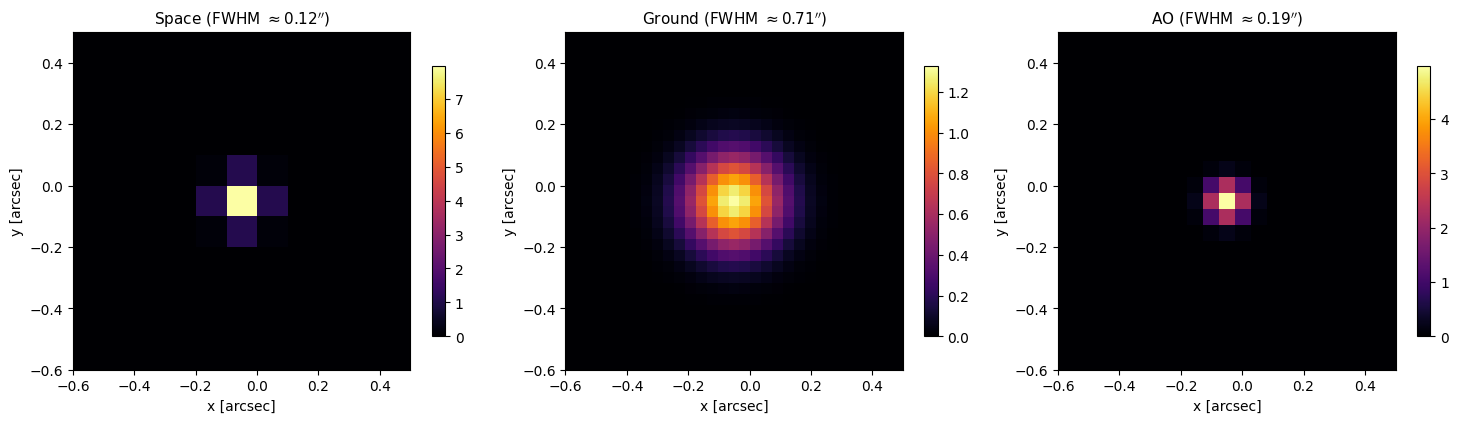

In [3]:
# ============================================================
# VISUALIZE PSFs
# ============================================================
# The dramatic difference in resolution between space, ground,
# and AO observations directly impacts what we can learn about
# the lens mass and source structure.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, psf, title in zip(
    axes,
    [psf_space, psf_ground, psf_ao],
    [r"Space (FWHM $\approx 0.12''$)",
     r"Ground (FWHM $\approx 0.71''$)",
     r"AO (FWHM $\approx 0.19''$)"],
):
    im = ax.imshow(
        psf.kernel.native, origin="lower", cmap="inferno",
        extent=[
            -11//2 * pixel_scales,
            11//2 * pixel_scales,
            -11//2 * pixel_scales,
            11//2 * pixel_scales,
        ],
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x [arcsec]')
    ax.set_ylabel('y [arcsec]')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


---

## 3. The Simulator Object <a id="3-the-simulator-object"></a>

### Theory: Noise in CCD Imaging

The noise in a CCD image has several components:

1. **Poisson noise** (shot noise): $\sigma_{\text{photon}} = \sqrt{N}$ where $N$ is the
   number of detected photons. Dominant for bright sources.

2. **Sky background**: diffuse light from the atmosphere/zodiacal light. Adds a uniform
   background level whose Poisson fluctuation contributes noise.

3. **Read noise**: electronic noise from reading the CCD. Typically 3–10 $e^-$/pixel.

The total noise per pixel is:

$$
\sigma_{\text{total}} = \sqrt{F_{\text{source}} \cdot t + F_{\text{sky}} \cdot t + \sigma_{\text{read}}^2}
$$

where $F$ are flux rates (electrons/sec) and $t$ is exposure time.

The **signal-to-noise ratio** (SNR) determines what we can resolve:
$\text{SNR} = F_{\text{source}} \cdot t \,/\, \sigma_{\text{total}}$.

PyAutoLens's `SimulatorImaging` handles all of this automatically.

In [4]:
# ============================================================
# DEFINE THE LENS SYSTEM
# ============================================================
# We use the same SIE + Sersic system from Module 01, but now
# we'll simulate it as realistic telescope data.
#
# al.convert.ell_comps_from() is a convenience function that
# converts (axis_ratio, angle) to the (ε₁, ε₂) parameterization
# that PyAutoLens uses internally.
# ============================================================

lens_galaxy = al.Galaxy(
    redshift=0.5,
    bulge=al.lp.Sersic(
        centre=(0.0, 0.0),
        ell_comps=al.convert.ell_comps_from(axis_ratio=0.9, angle=45.0),
        intensity=2.0,              # Bright lens (electrons/sec/arcsec²)
        effective_radius=0.6,       # Compact elliptical
        sersic_index=3.0,           # Between exponential and de Vaucouleurs
    ),
    mass=al.mp.Isothermal(
        centre=(0.0, 0.0),
        ell_comps=al.convert.ell_comps_from(axis_ratio=0.9, angle=45.0),
        einstein_radius=1.6,
    ),
    shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05),
)

source_galaxy = al.Galaxy(
    redshift=1.0,
    bulge=al.lp.SersicCore(
        centre=(0.1, 0.05),         # Slightly offset → asymmetric arcs
        ell_comps=al.convert.ell_comps_from(axis_ratio=0.8, angle=60.0),
        intensity=4.0,
        effective_radius=0.1,       # Compact source
        sersic_index=1.0,
    ),
)

tracer = al.Tracer(galaxies=[lens_galaxy, source_galaxy])

In [5]:
# ============================================================
# CREATE THE GRID
# ============================================================
# 100x100 pixels at 0.1"/pixel → 10" x 10" field of view.
# This is sufficient for a lens with θ_E = 1.6".
# ============================================================

grid = al.Grid2D.uniform(
    shape_native=(100, 100),
    pixel_scales=0.1,
)

/opt/anaconda3/envs/autolens/lib/python3.12/site-packages/autoarray/operators/convolver.py:919: UserWarning: No blurring_image provided. Only the direct image will be convolved. This may change the correctness of the PSF convolution.
  warnings.warn(


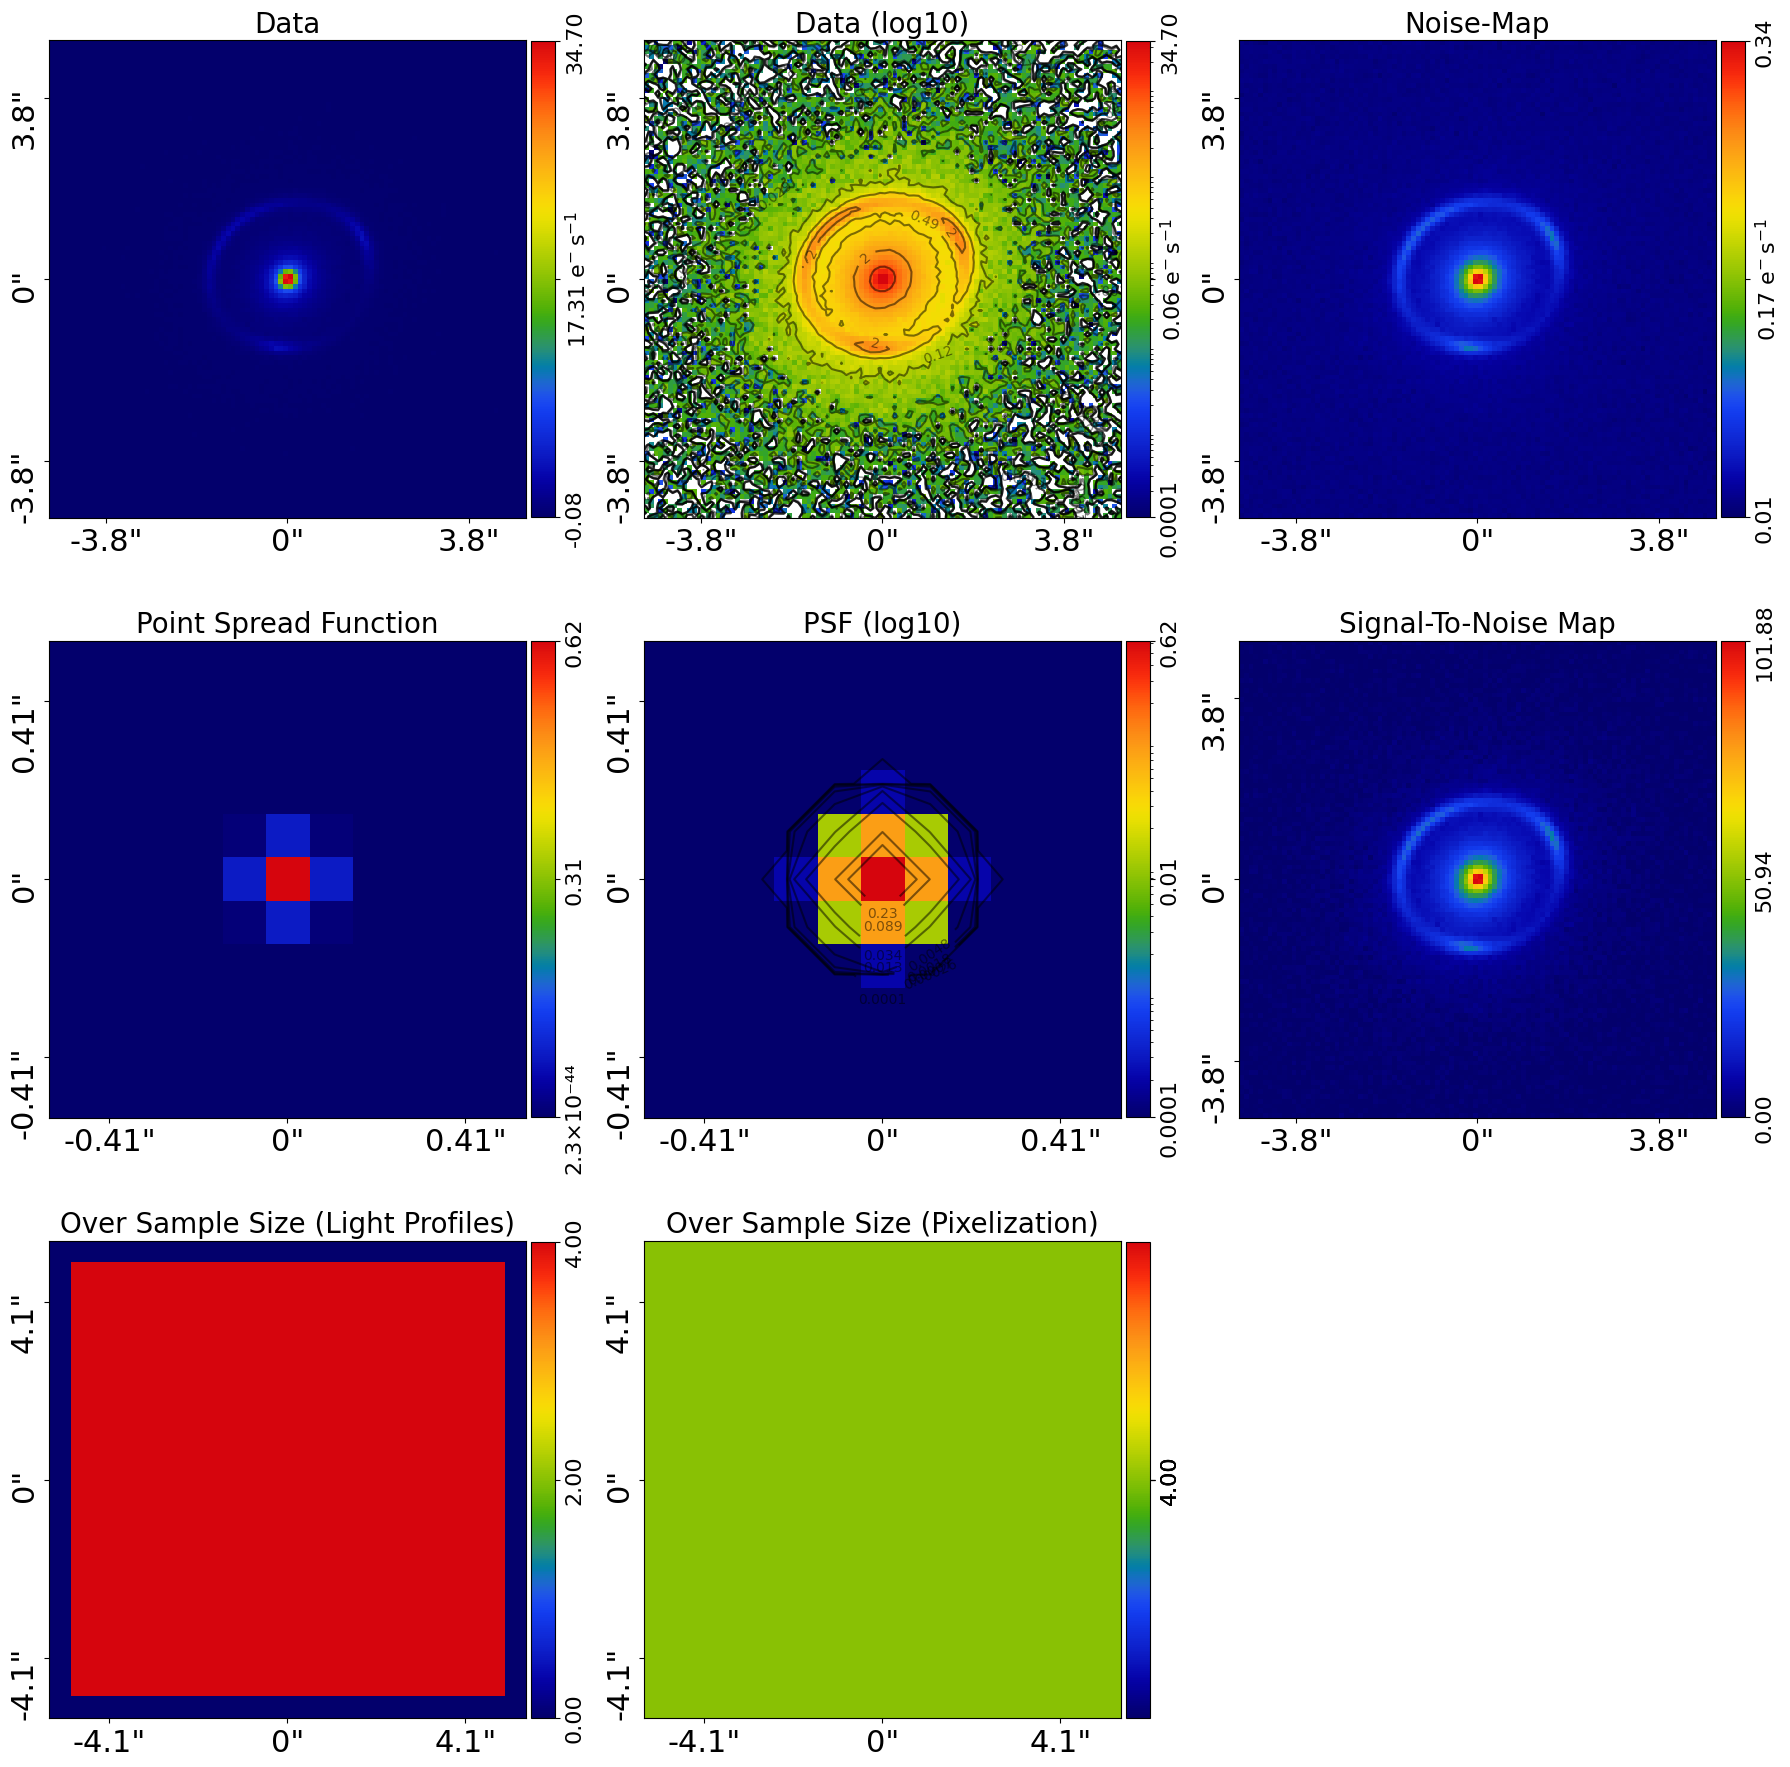

In [6]:
# ============================================================
# SIMULATE: SPACE-BASED OBSERVATION
# ============================================================
# SimulatorImaging takes:
#   exposure_time:           total integration time (seconds)
#   psf:                     the PSF kernel to convolve with
#   background_sky_level:    sky background (electrons/sec/arcsec²)
#   add_poisson_noise_to_data: whether to add shot noise
#
# The simulator then:
#   1. Evaluates the Tracer image on the grid
#   2. Convolves with the PSF
#   3. Multiplies by exposure time to get electron counts
#   4. Adds Poisson noise
#   5. Computes the noise map
#   6. Returns an Imaging dataset object
# ============================================================

simulator_space = al.SimulatorImaging(
    exposure_time=300.0,           # 5-minute exposure
    psf=psf_space,
    background_sky_level=0.1,      # Low sky (space)
    add_poisson_noise_to_data=True,
)

# Generate the mock dataset
dataset_space = simulator_space.via_tracer_from(tracer=tracer, grid=grid)

# Visualize the dataset: data, noise map, PSF, signal-to-noise
aplt.subplot_imaging_dataset(dataset=dataset_space)

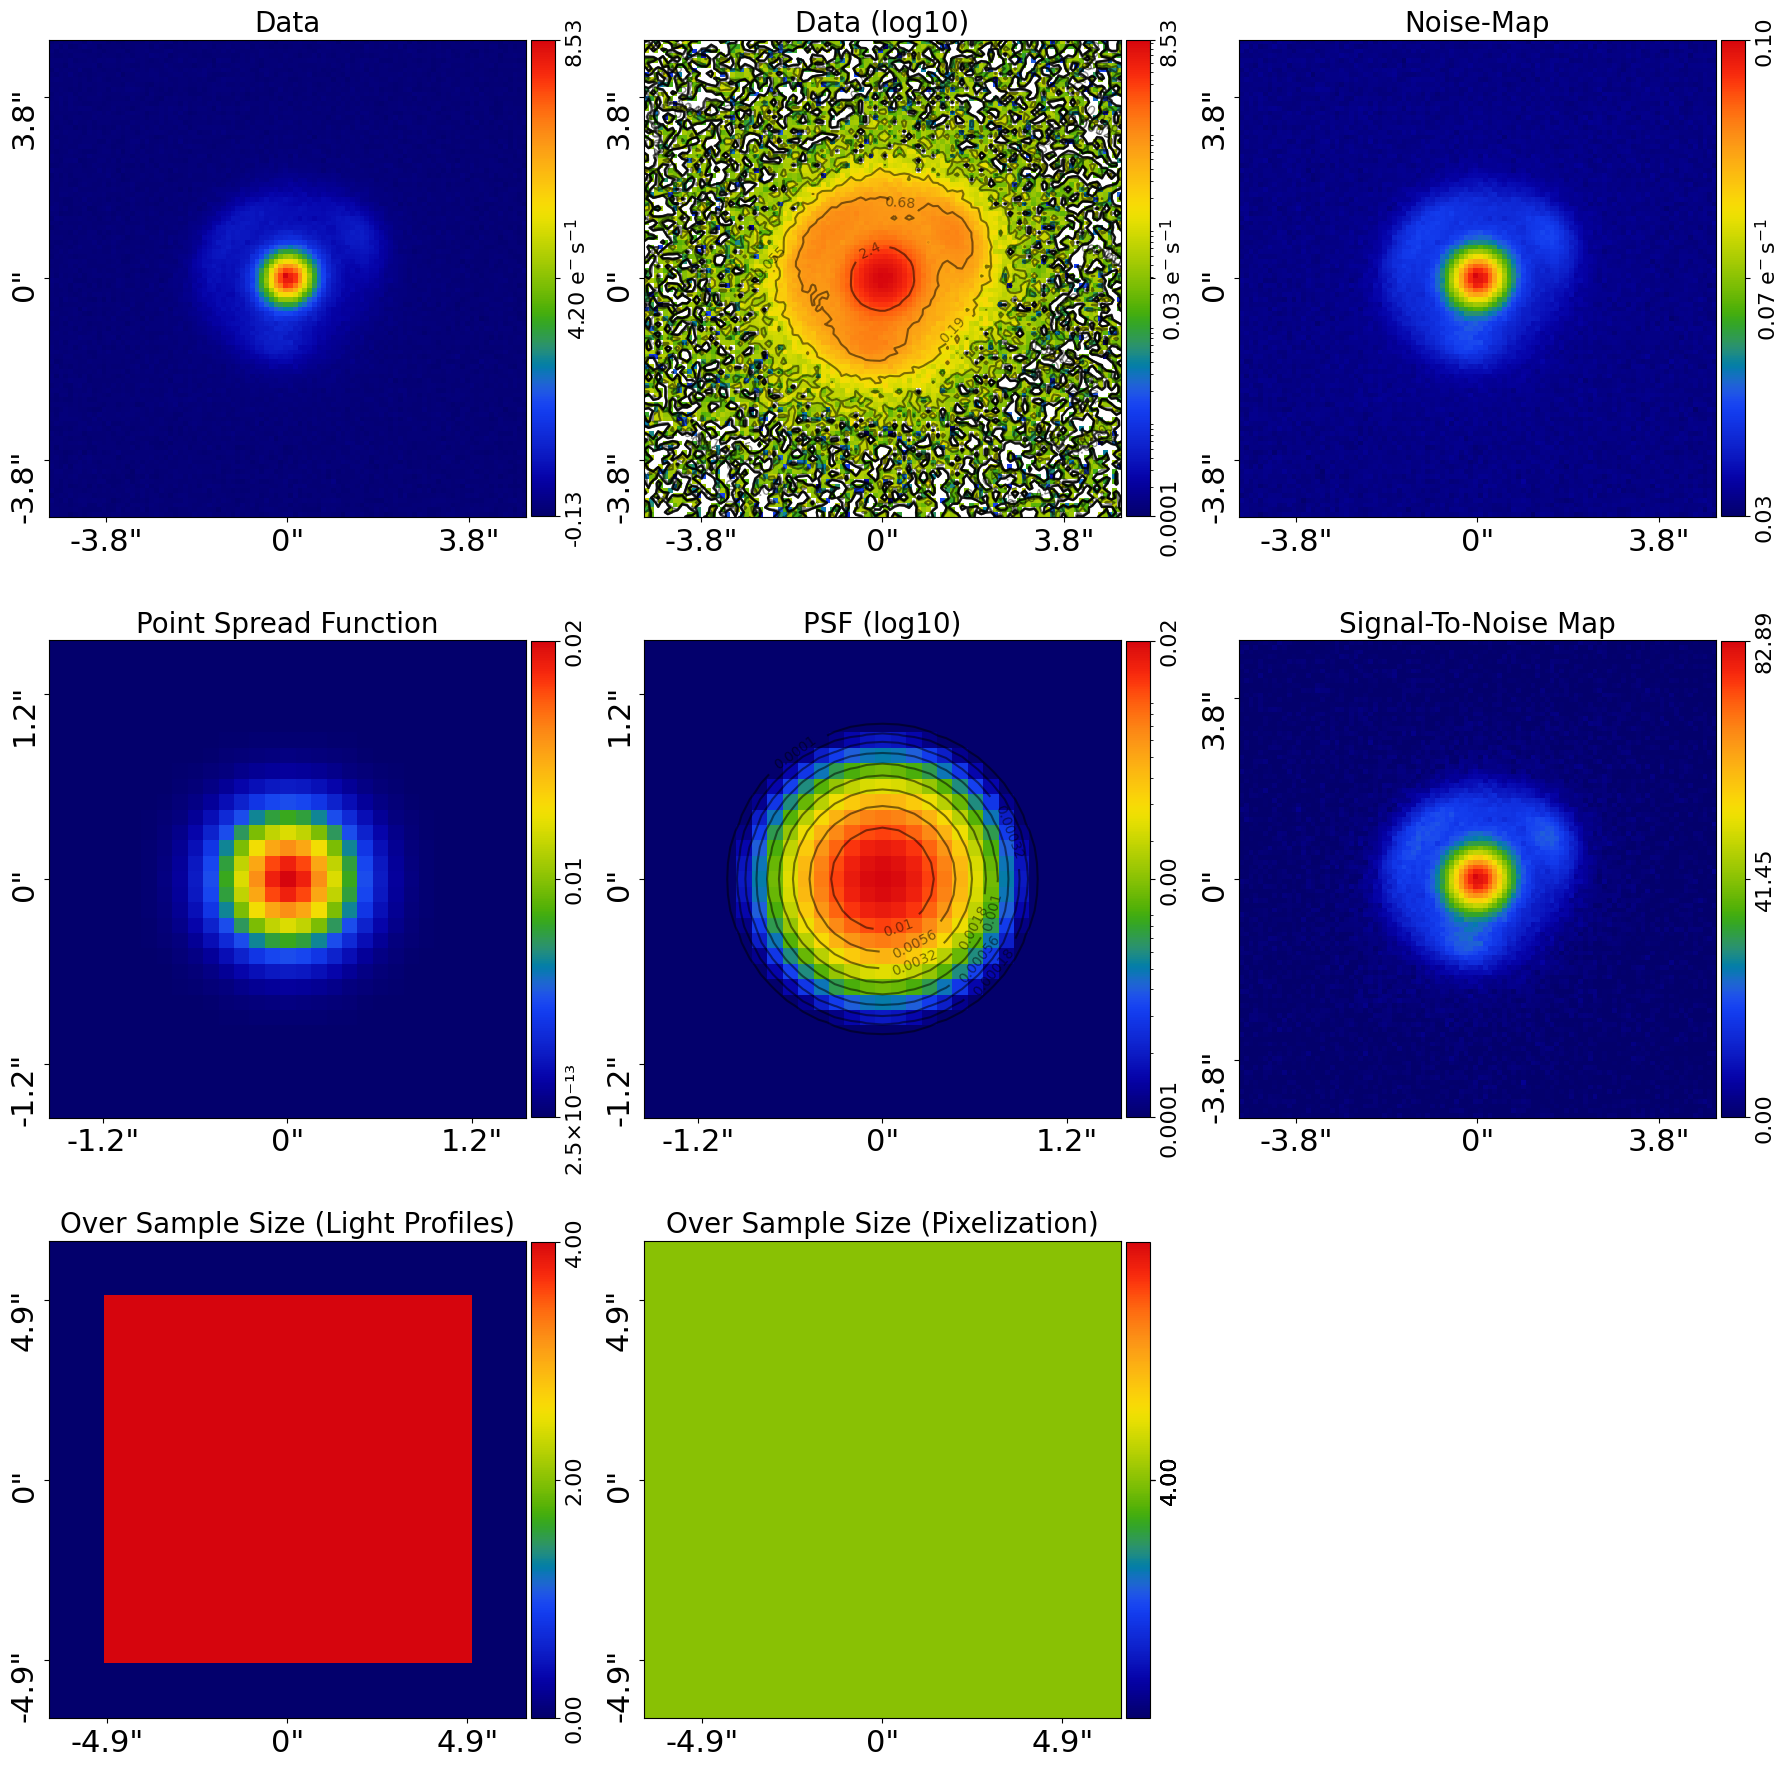

In [7]:
# ============================================================
# SIMULATE: GROUND-BASED OBSERVATION
# ============================================================
# Same lens system, but now with seeing-limited resolution and
# higher sky background. Notice how much information is lost.
# ============================================================

simulator_ground = al.SimulatorImaging(
    exposure_time=900.0,           # Longer exposure to compensate
    psf=psf_ground,
    background_sky_level=1.0,      # High sky (ground)
    add_poisson_noise_to_data=True,
)

dataset_ground = simulator_ground.via_tracer_from(tracer=tracer, grid=grid)
aplt.subplot_imaging_dataset(dataset=dataset_ground)

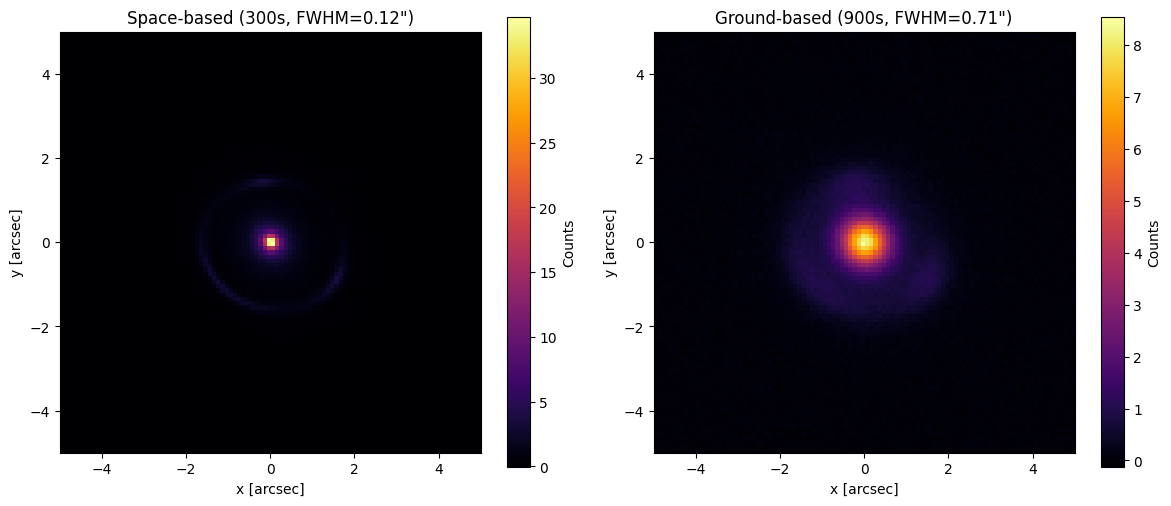

In [8]:
# ============================================================
# SIDE-BY-SIDE: SPACE vs. GROUND
# ============================================================
# This comparison illustrates why space-based data is essential
# for detailed lens modeling. The arcs are resolved in space
# but smeared into the lens light on the ground.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, dataset, title in zip(
    axes,
    [dataset_space, dataset_ground],
    ["Space-based (300s, FWHM=0.12\")",
     "Ground-based (900s, FWHM=0.71\")"]
):
    im = ax.imshow(
        dataset.data.native,
        origin="lower",
        cmap="inferno",
        extent=[-5, 5, -5, 5],
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x [arcsec]')
    ax.set_ylabel('y [arcsec]')
    plt.colorbar(im, ax=ax, label="Counts")

plt.tight_layout()
plt.show()

---

## 4. Instrument Configurations: HST, Euclid, Ground-Based <a id="4-instrument-configurations"></a>

### Typical Parameters for Common Instruments

| Instrument | Pixel Scale | PSF FWHM | Exposure | Sky Level | Use Case |
|------------|------------|----------|----------|-----------|----------|
| **HST ACS/WFC3** | 0.05"/pix | 0.07"–0.10" | 2000s+ | 0.01 | Gold-standard imaging |
| **Euclid VIS** | 0.10"/pix | 0.16" | 2260s | 0.04 | Wide-field survey |
| **Keck AO** | 0.01"–0.04"/pix | 0.05"–0.08" | 600s+ | 0.5 | AO-corrected ground |
| **Seeing-limited** | 0.10"–0.25"/pix | 0.5"–1.5" | 900s+ | 1.0+ | Survey discovery |

(cf. Meneghetti Table 8.1; AGEL survey parameters)

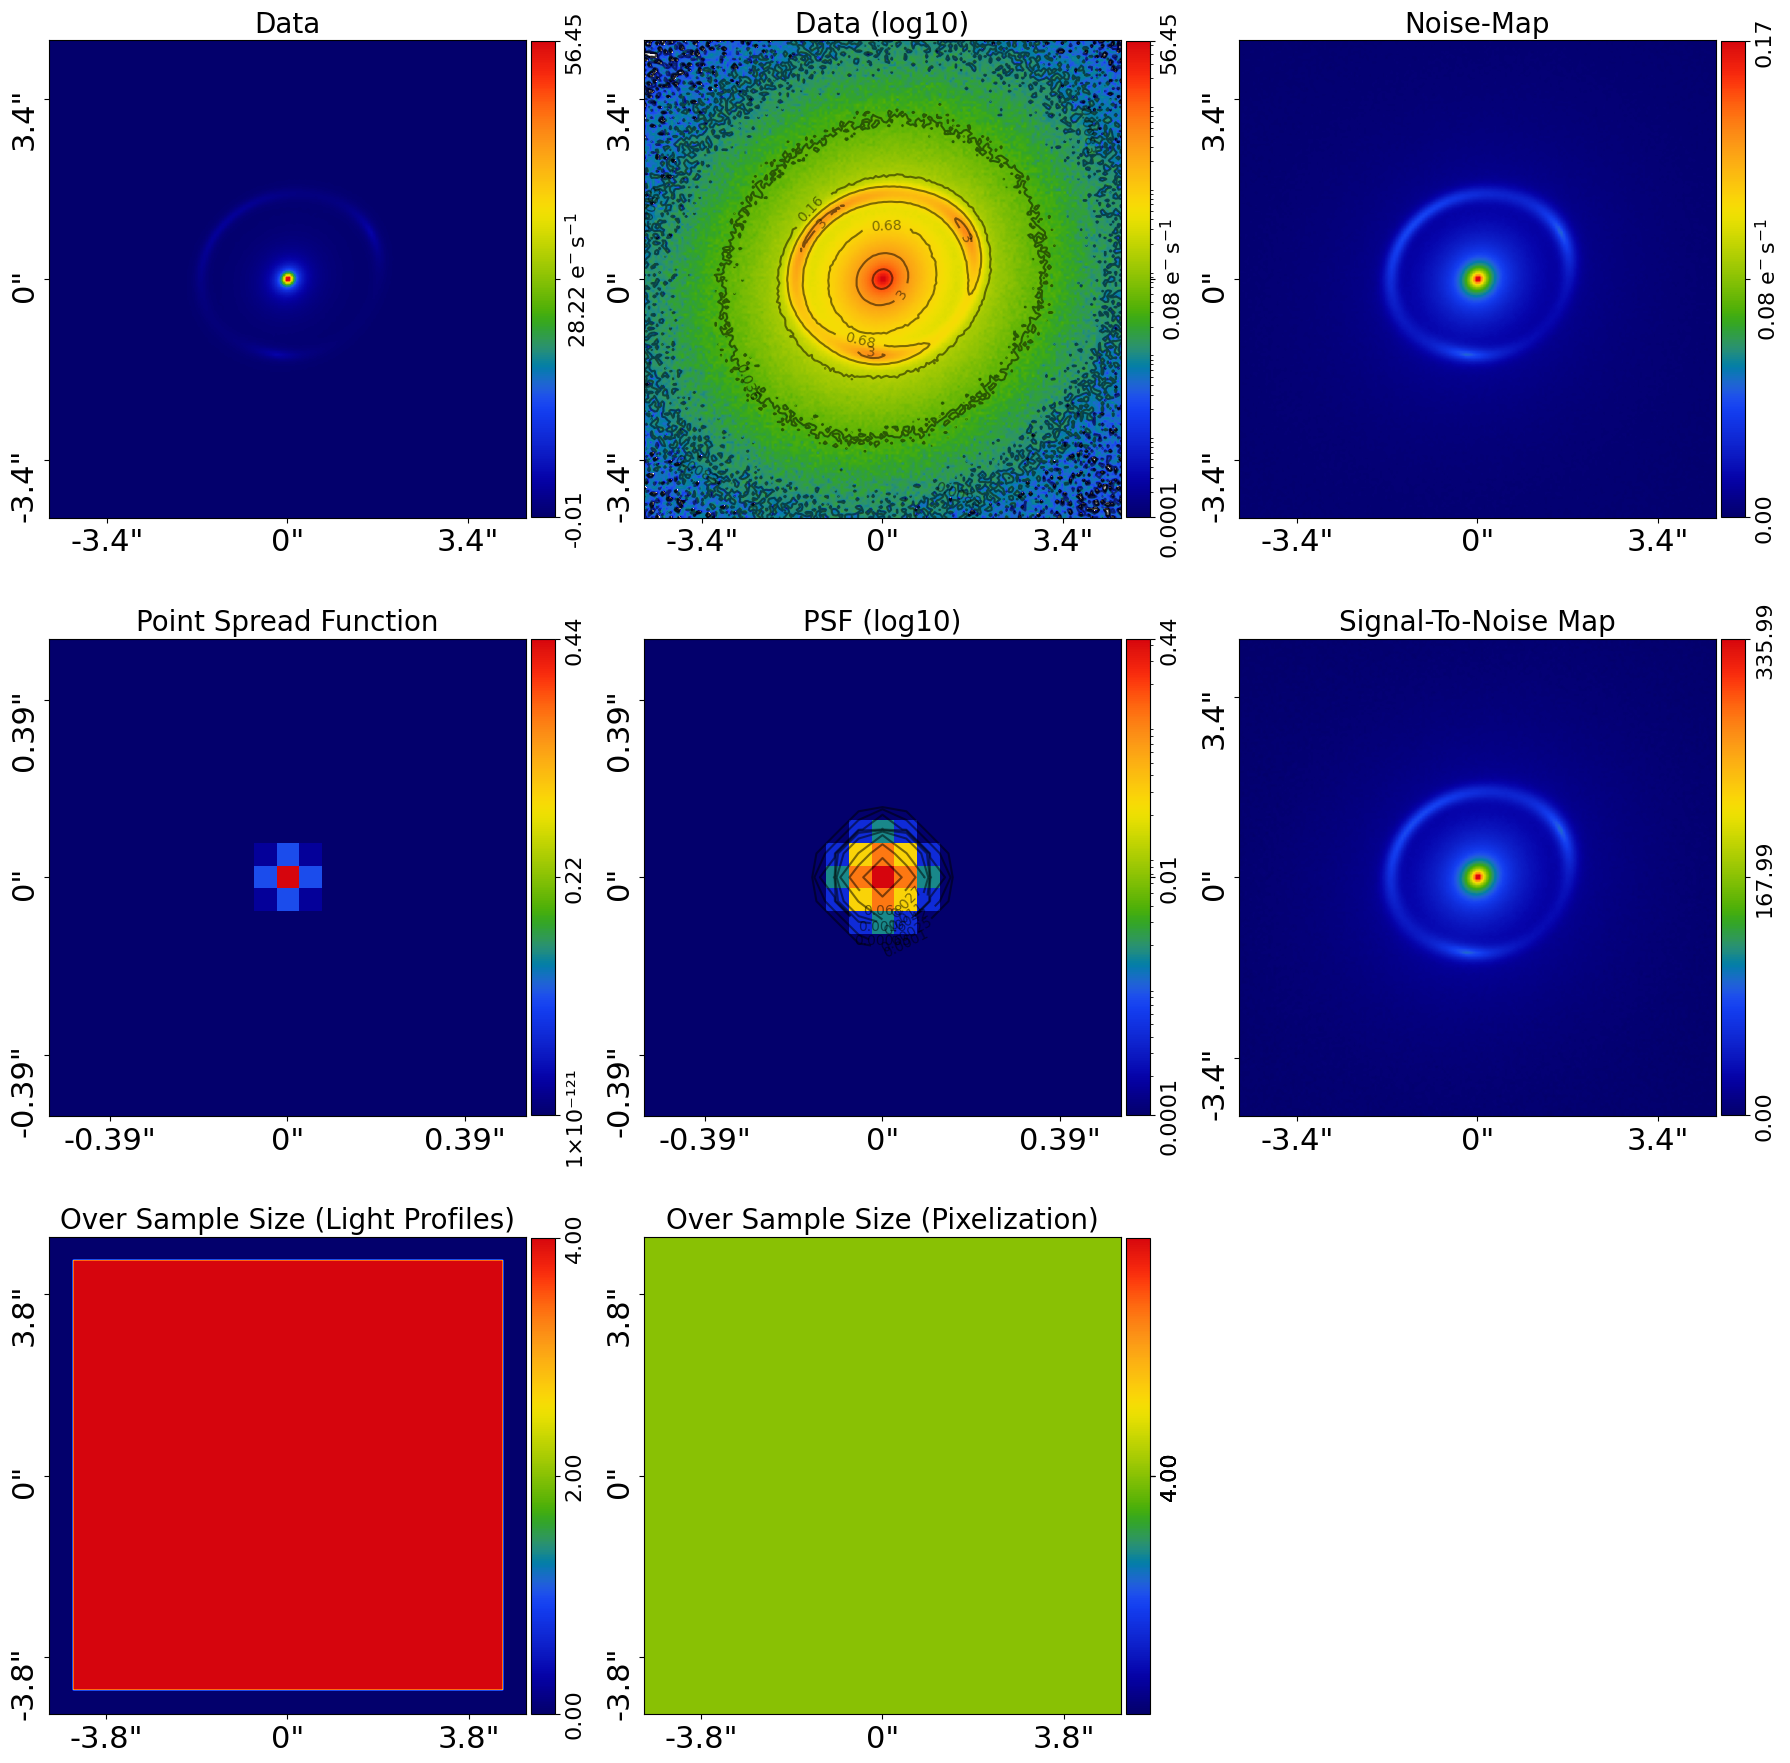

In [9]:
# ============================================================
# HST-LIKE SIMULATION
# ============================================================
# HST provides the highest resolution optical imaging available.
# With 0.05"/pixel and FWHM ~ 0.07", individual arc substructure
# and lens galaxy morphology are well resolved.
# ============================================================

# HST grid: finer pixel scale → more pixels for same field of view
grid_hst = al.Grid2D.uniform(
    shape_native=(180, 180),       # 180 x 180 pixels
    pixel_scales=0.05,             # 0.05"/pixel (HST ACS)
)

psf_hst = al.Convolver.from_gaussian(
    shape_native=(21, 21),
    sigma=0.03,                    # σ = 0.03" → FWHM ≈ 0.07"
    pixel_scales=0.05,
)

simulator_hst = al.SimulatorImaging(
    exposure_time=2000.0,          # Typical HST orbit (~33 min)
    psf=psf_hst,
    background_sky_level=0.01,     # Very low sky in space
    add_poisson_noise_to_data=True,
)

dataset_hst = simulator_hst.via_tracer_from(tracer=tracer, grid=grid_hst)
aplt.subplot_imaging_dataset(dataset=dataset_hst)


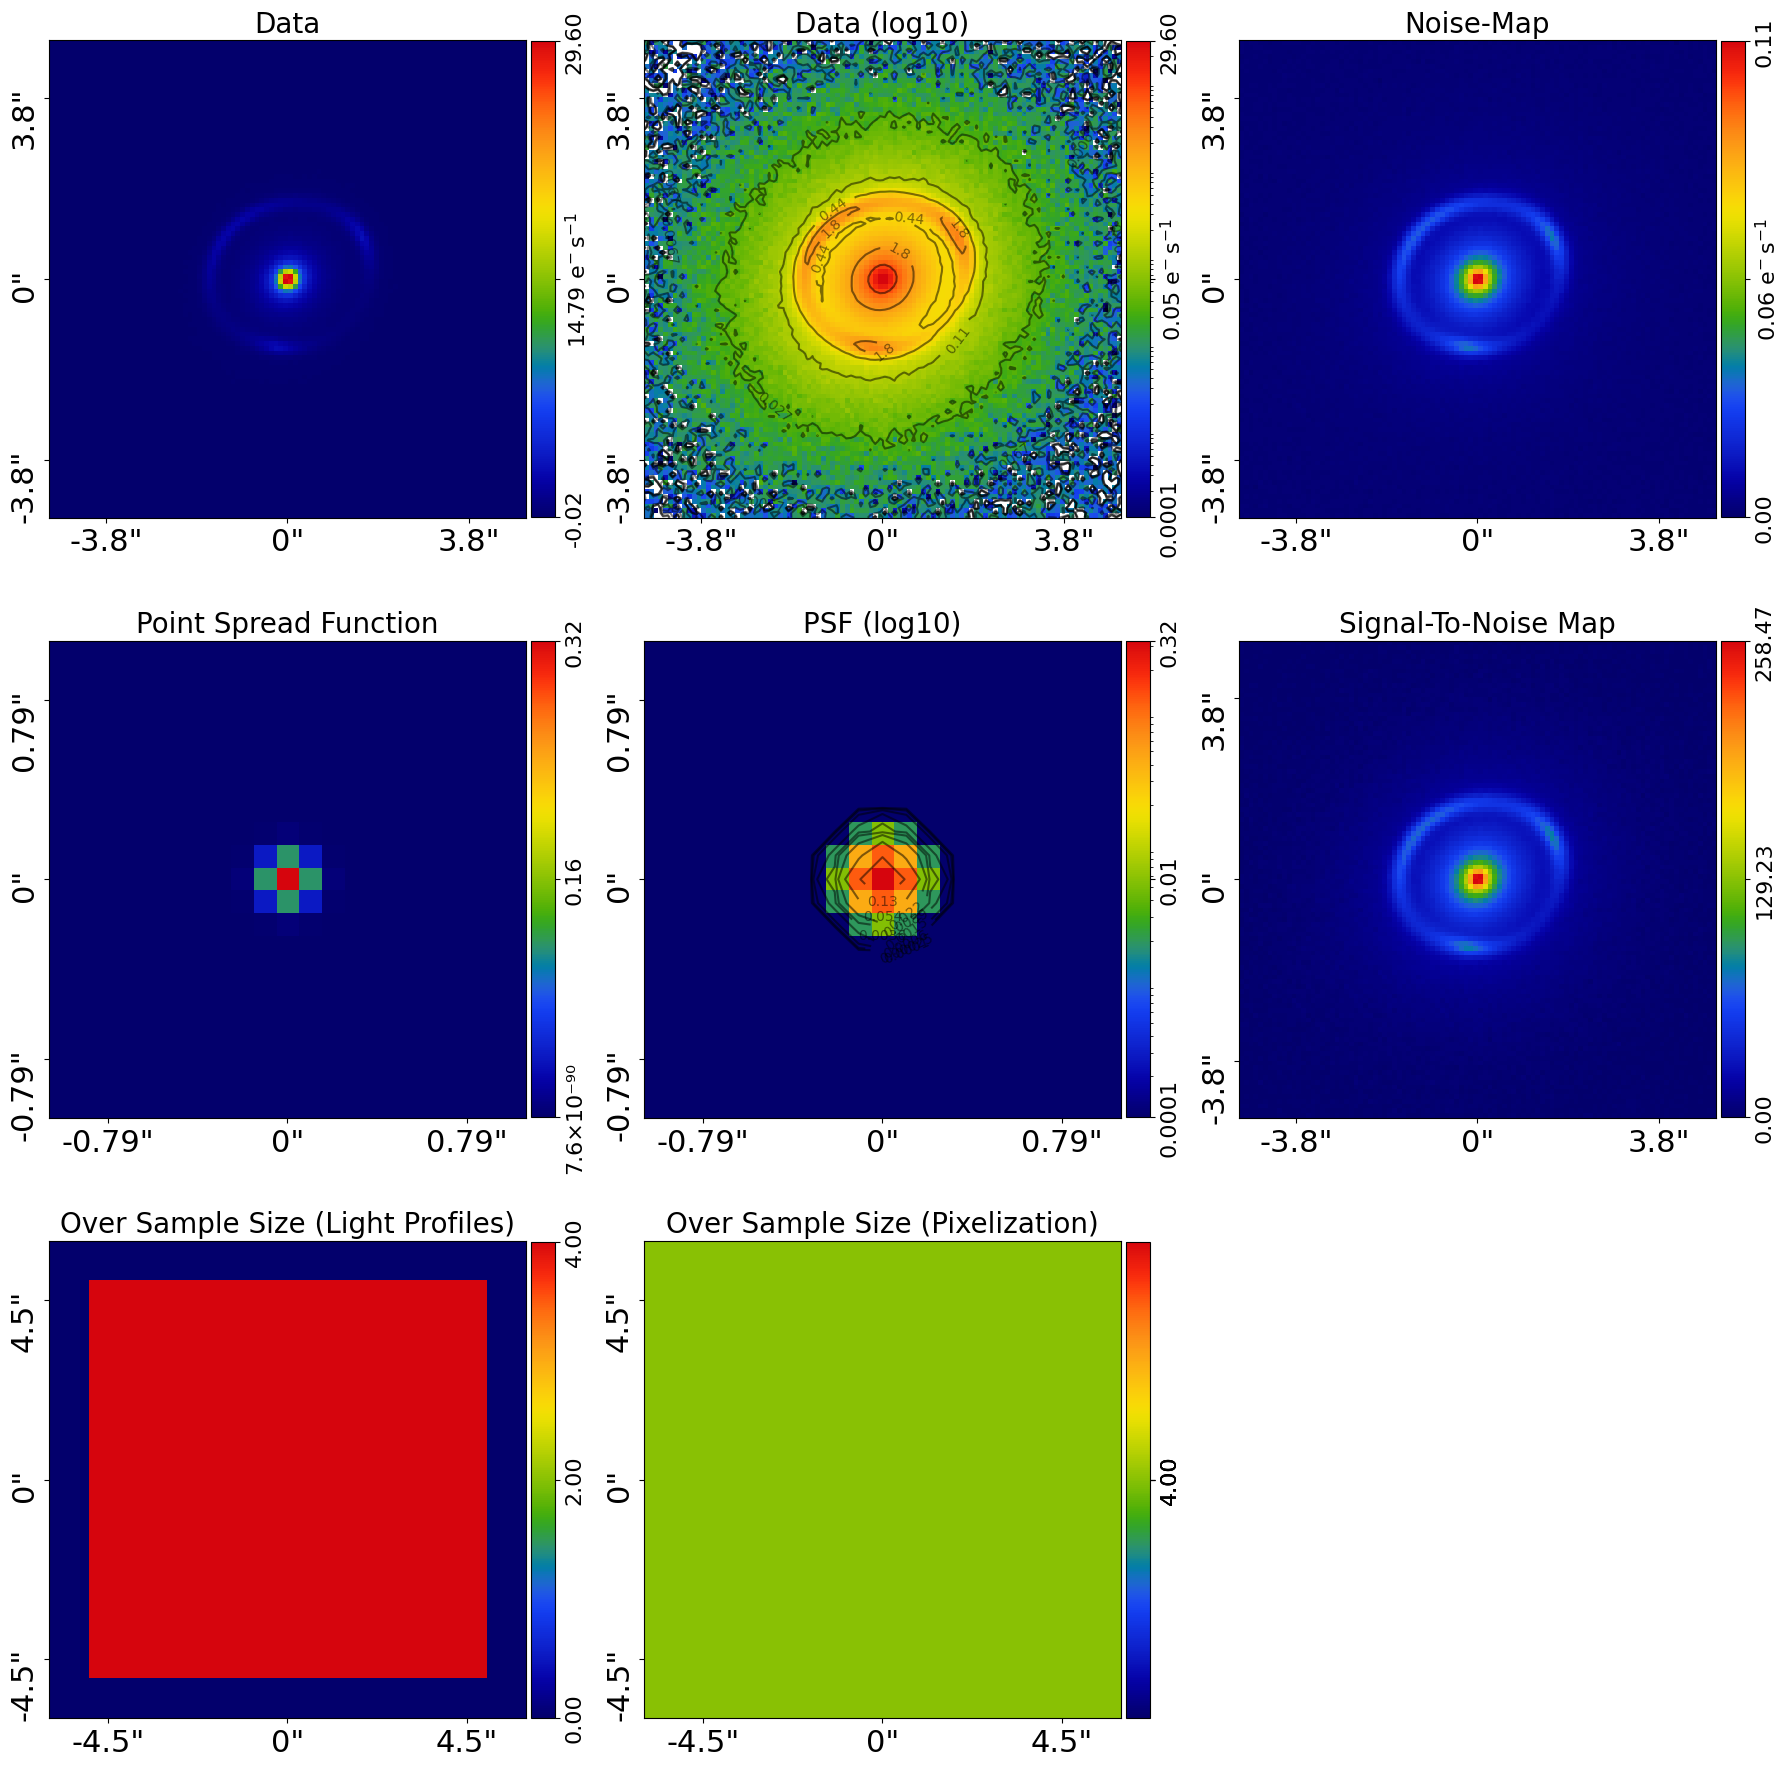

In [10]:
# ============================================================
# EUCLID-LIKE SIMULATION
# ============================================================
# Euclid (launched 2023) will discover ~100,000 new lenses.
# Its VIS instrument has 0.1"/pixel — coarser than HST but
# the huge survey area is transformative.
# ============================================================

grid_euclid = al.Grid2D.uniform(
    shape_native=(100, 100),
    pixel_scales=0.1,
)

psf_euclid = al.Convolver.from_gaussian(
    shape_native=(21, 21),
    sigma=0.07,                    # σ = 0.07" → FWHM ≈ 0.16"
    pixel_scales=0.1,
)

simulator_euclid = al.SimulatorImaging(
    exposure_time=2260.0,          # Euclid VIS nominal exposure
    psf=psf_euclid,
    background_sky_level=0.04,     # Low sky (L2 orbit)
    add_poisson_noise_to_data=True,
)

dataset_euclid = simulator_euclid.via_tracer_from(tracer=tracer, grid=grid_euclid)
aplt.subplot_imaging_dataset(dataset=dataset_euclid)


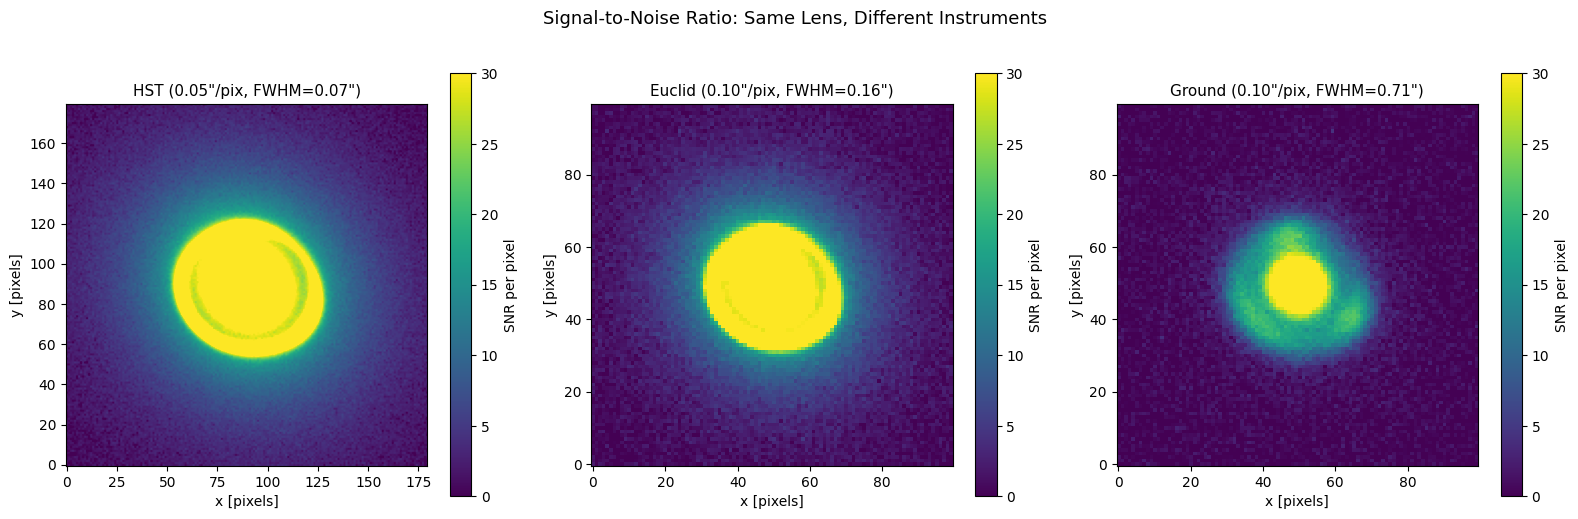

In [11]:
# ============================================================
# THREE-INSTRUMENT COMPARISON
# ============================================================
# The same lens system observed with three different instruments.
# Notice how the signal-to-noise in the arcs and the ability
# to separate lens light from source light varies dramatically.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (dataset_hst, "HST (0.05\"/pix, FWHM=0.07\")"),
    (dataset_euclid, "Euclid (0.10\"/pix, FWHM=0.16\")"),
    (dataset_ground, "Ground (0.10\"/pix, FWHM=0.71\")"),
]

for ax, (ds, title) in zip(axes, configs):
    # Use signal-to-noise map for comparison
    snr = ds.data.native / ds.noise_map.native
    im = ax.imshow(
        snr,
        origin="lower",
        cmap="viridis",
        vmin=0, vmax=30,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')
    plt.colorbar(im, ax=ax, label="SNR per pixel")

plt.suptitle("Signal-to-Noise Ratio: Same Lens, Different Instruments", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Over-Sampling: Getting Sub-Pixel Physics Right <a id="5-over-sampling"></a>

### Theory: Sub-Pixel Integration

A single pixel integrates the surface brightness over its area. If the brightness
varies significantly within a pixel (e.g., near the center of a steep Sérsic profile
or at the Einstein radius where arcs are thin), evaluating the profile at just the
pixel center introduces error.

**Over-sampling** subdivides each pixel into $N \times N$ sub-pixels, evaluates the
profile at each sub-pixel, and averages. This is especially important:
- Near the lens center (steep light profile gradients)
- At the Einstein radius (thin arc structures)

PyAutoLens uses **adaptive radial over-sampling**: high resolution near the center,
lower resolution in the outskirts where profiles are smooth.

In [12]:
# ============================================================
# ADAPTIVE OVER-SAMPLING
# ============================================================
# over_sample_size_via_radial_bins_from() creates a map where
# each pixel has a different over-sampling level based on its
# distance from specified centers.
#
# sub_size_list: [32, 8, 2] means:
#   - Within radial_list[0]: 32x32 sub-pixels (1024 evaluations!)
#   - Between radial_list[0] and radial_list[1]: 8x8 (64)
#   - Outside radial_list[1]: 2x2 (4)
#
# This is much more efficient than uniform over-sampling.
# ============================================================

grid_for_oversample = al.Grid2D.uniform(
    shape_native=(100, 100),
    pixel_scales=0.1,
)

over_sample_size = al.util.over_sample.over_sample_size_via_radial_bins_from(
    grid=grid_for_oversample,
    sub_size_list=[32, 8, 2],       # Decreasing resolution outward
    radial_list=[0.3, 0.6],         # Transition radii (arcsec)
    centre_list=[(0.0, 0.0)],       # Center(s) to oversample around
)

grid_oversampled = grid_for_oversample.apply_over_sampling(
    over_sample_size=over_sample_size
)

print(f"Over-sample map shape: {over_sample_size.shape}")
print(f"Center pixel over-sampling: {over_sample_size[50*100+50]}x")
print(f"Edge pixel over-sampling: {over_sample_size[0]}x")

Over-sample map shape: (10000,)
Center pixel over-sampling: 32.0x
Edge pixel over-sampling: 2.0x


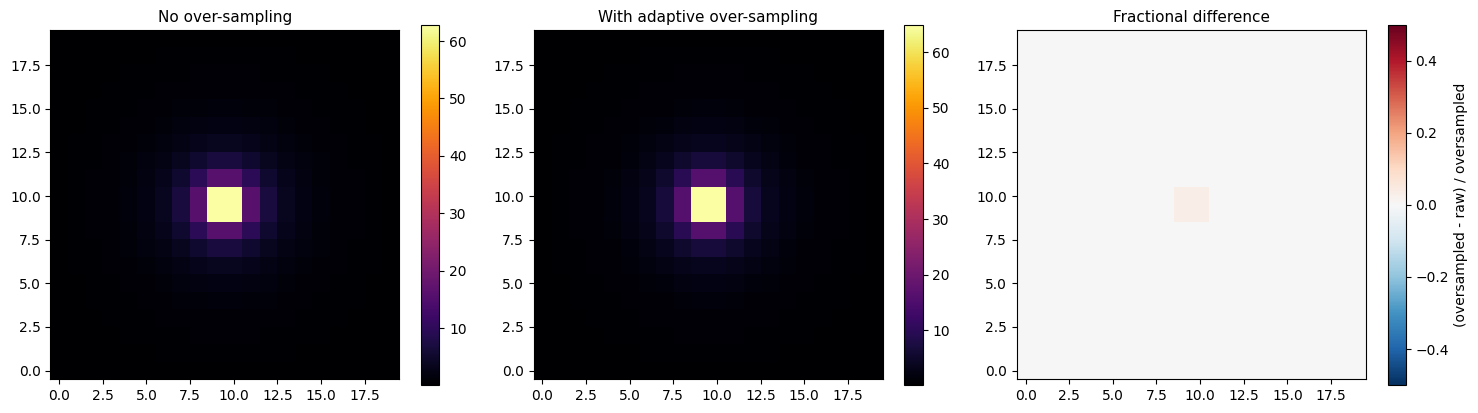

Max fractional difference in center: 3.29%


In [13]:
# ============================================================
# EFFECT OF OVER-SAMPLING
# ============================================================
# Compare the central region of a steep Sersic profile with
# and without over-sampling. Without it, the central pixel
# value can be significantly wrong.
# ============================================================

steep_sersic = al.lp.Sersic(
    centre=(0.0, 0.0),
    ell_comps=(0.0, 0.0),
    intensity=5.0,
    effective_radius=0.3,          # Very compact
    sersic_index=4.0,              # Steep central cusp
)

# Without over-sampling
image_no_oversample = steep_sersic.image_2d_from(grid=grid_for_oversample)

# With over-sampling
image_oversampled = steep_sersic.image_2d_from(grid=grid_oversampled)

# Compare central region
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Zoom into central 20x20 pixels
sl = slice(40, 60)

im0 = axes[0].imshow(image_no_oversample.native[sl, sl], origin="lower", cmap="inferno")
axes[0].set_title("No over-sampling", fontsize=11)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(image_oversampled.native[sl, sl], origin="lower", cmap="inferno")
axes[1].set_title("With adaptive over-sampling", fontsize=11)
plt.colorbar(im1, ax=axes[1])

# Fractional difference
frac_diff = (image_oversampled.native[sl, sl] - image_no_oversample.native[sl, sl]) / (
    image_oversampled.native[sl, sl] + 1e-10
)
im2 = axes[2].imshow(frac_diff, origin="lower", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[2].set_title("Fractional difference", fontsize=11)
plt.colorbar(im2, ax=axes[2], label="(oversampled - raw) / oversampled")

plt.tight_layout()
plt.show()

print(f"Max fractional difference in center: {np.max(np.abs(frac_diff)):.2%}")

---

## 6. Saving and Loading Datasets (FITS) <a id="6-saving-and-loading-datasets"></a>

### FITS: The Astronomer's Data Format

**FITS** (Flexible Image Transport System) is the standard data format in astronomy.
A lens dataset requires three FITS files:
1. **`data.fits`**: the observed image (electrons or counts)
2. **`noise_map.fits`**: the 1σ noise per pixel
3. **`psf.fits`**: the PSF kernel

PyAutoLens can save and load datasets in this format, making it interoperable with
all standard astronomy tools (ds9, astropy, etc.).

In [14]:
# ============================================================
# SAVE DATASET TO FITS
# ============================================================
# output_to_fits saves the three required files for lens
# modeling. We also save the tracer as JSON for reference.
# ============================================================

dataset_path = Path("output") / "simulated_datasets" / "hst_like"
dataset_path.mkdir(parents=True, exist_ok=True)

aplt.fits_imaging(dataset=dataset_hst,
    data_path=dataset_path / "data.fits",
    psf_path=dataset_path / "psf.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    overwrite=True,
)

# Save the true model for later comparison
al.output_to_json(
    obj=tracer,
    file_path=dataset_path / "tracer.json",
)

print(f"Dataset saved to: {dataset_path}")
print(f"Files: {[f.name for f in dataset_path.iterdir()]}")

Dataset saved to: output/simulated_datasets/hst_like
Files: ['psf.fits', 'data.fits', 'noise_map.fits', 'tracer.json']


Loaded dataset shape: (180, 180)
Pixel scales: (0.05, 0.05)


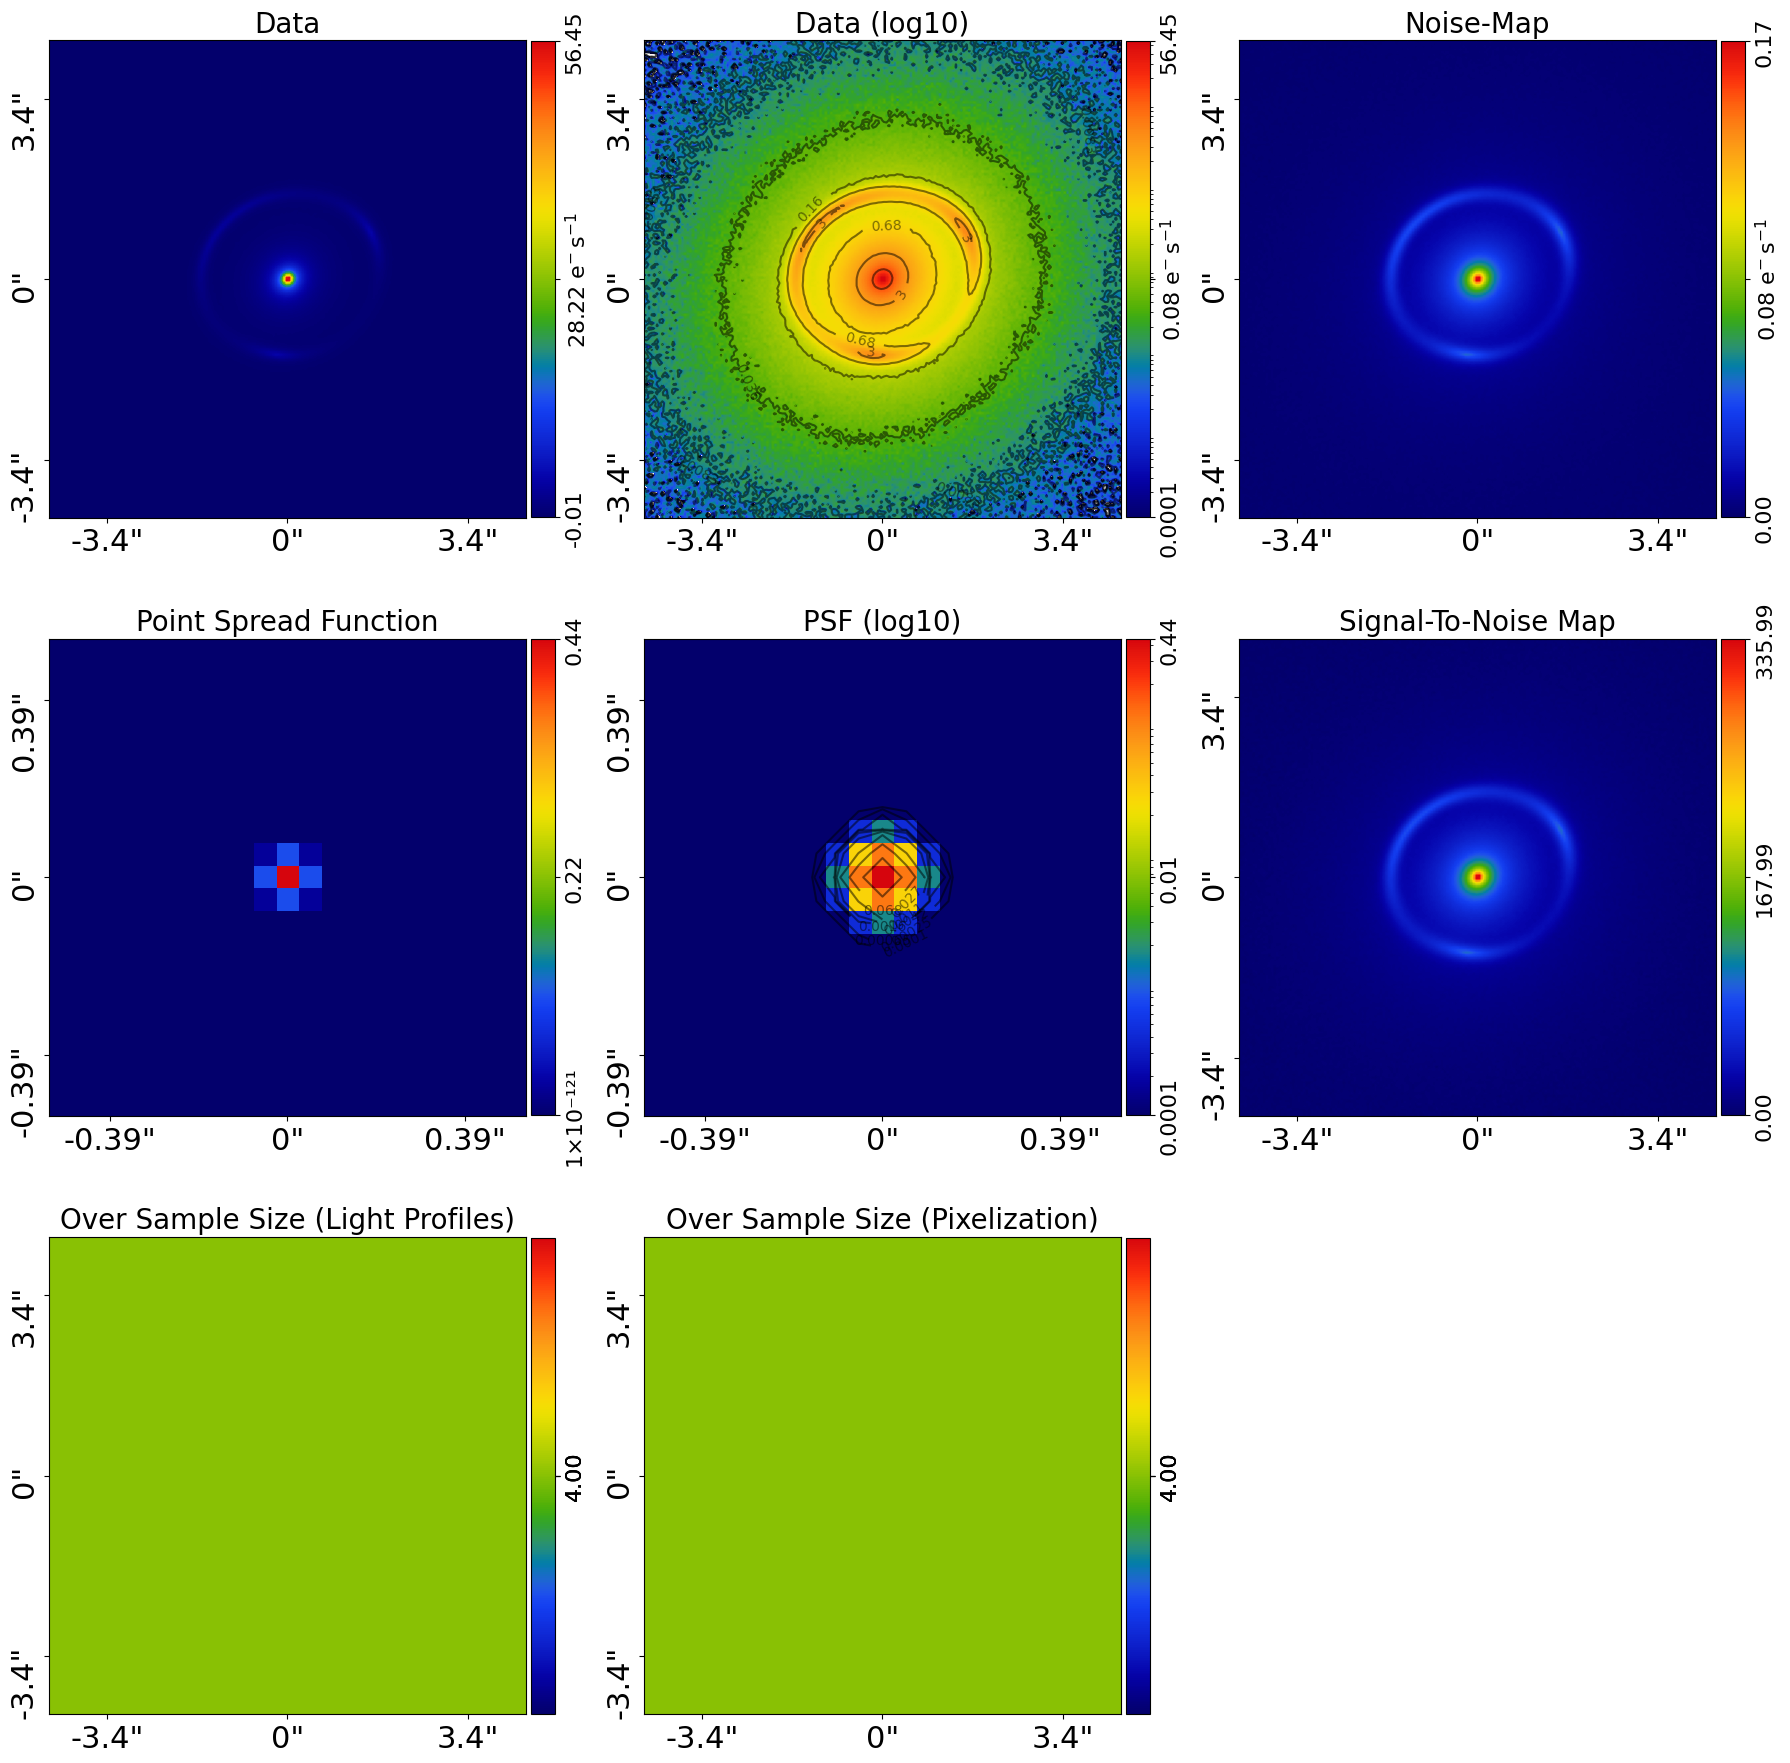

In [15]:
# ============================================================
# LOAD DATASET FROM FITS
# ============================================================
# This is how you'll load real data or previously simulated
# data for modeling in Module 03.
#
# Imaging.from_fits loads all three components and creates
# a dataset object ready for analysis.
# ============================================================

dataset_loaded = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    psf_path=dataset_path / "psf.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    pixel_scales=0.05,             # Must match the original!
)

print(f"Loaded dataset shape: {dataset_loaded.shape_native}")
print(f"Pixel scales: {dataset_loaded.pixel_scales}")

# Verify it matches
aplt.subplot_imaging_dataset(dataset=dataset_loaded)

---

## 7. Exercises <a id="7-exercises"></a>

### Exercise 1: Exposure Time and SNR

Using the Euclid-like configuration, simulate the same lens with exposure times of
100s, 1000s, and 10000s. How does the SNR in the lensed arcs change? At what exposure
time can you first clearly distinguish the arcs from the noise?

### Exercise 2: No Lens Light

Create a lens galaxy with **mass but no light** (i.e., a dark lens) and simulate it
with the HST configuration. How does the image differ? This is the idealized case
that simplifies modeling — no deblending needed.

### Exercise 3: Complex Source Morphology

Replace the single Sérsic source with a **two-component source** (bulge + disk):
- Bulge: $n = 4$, $R_e = 0.05''$, centered at $(0.1, 0.05)$
- Disk: $n = 1$, $R_e = 0.3''$, centered at $(0.1, 0.05)$

Simulate with HST parameters. How does the lensed image change compared to the
single-component source? This motivates the pixelized source reconstructions in Module 05.

### Exercise 4: Loading Real Data

Load one of the example datasets from the autolens_workspace:
```python
dataset = al.Imaging.from_fits(
    data_path="../../autolens_workspace_original/dataset/imaging/simple/data.fits",
    psf_path="../../autolens_workspace_original/dataset/imaging/simple/psf.fits",
    noise_map_path="../../autolens_workspace_original/dataset/imaging/simple/noise_map.fits",
    pixel_scales=0.1,
)
```
Plot the data, noise map, and signal-to-noise. Can you identify the lensed arcs by eye?

---

## Summary

| Concept | Implementation | Theory |
|---------|---------------|--------|
| Forward model | `SimulatorImaging.via_tracer_from()` | Nightingale+18 Sec. 3 |
| PSF | `Convolver.from_gaussian()` | Instrument optics + atmosphere |
| Noise | Poisson + sky background | CCD statistics |
| Over-sampling | `over_sample_size_via_radial_bins_from()` | Sub-pixel integration |
| FITS I/O | `output_to_fits()` / `Imaging.from_fits()` | Astronomy standard |

**Next module:** Now that we can simulate realistic data, we'll learn to **model** it —
the inverse problem of recovering the lens parameters from the observed image.

---

*Learning to Autolens — Module 02*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*
